In [23]:
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU!")
print("CUDA:", torch.version.cuda)


GPU: Tesla T4
CUDA: 12.8


In [24]:
!pip install -q torch torchvision matplotlib seaborn scikit-learn pillow tqdm opencv-python-headless


In [25]:
from google.colab import drive
drive.mount('/content/drive')
import os
Base = "/content/drive/MyDrive/disease_data"
for f in ["chest_xray","COVID-19_Radiography_Dataset","TB_Chest_Radiography_Database"]:
  p = os.path.join(Base,f)
  print(f" {f}:{'yes' if os.path.exists(p) else 'NO'}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 chest_xray:yes
 COVID-19_Radiography_Dataset:yes
 TB_Chest_Radiography_Database:yes


In [26]:
import os, random , shutil , json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import Counter
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from sklearn.metrics import classification_report, confusion_matrix


torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:",device)



Device: cuda


In [36]:
Classes = ["Normal", "Pneumonia", "COVID", "Lung_Opacity", "Tuberculosis"]
Base_Out = "/content/disease_combined"
for cls in Classes:
  os.makedirs(f"{Base_Out}/{cls}", exist_ok=True)

def copy_images(src, dest_cls, limit=3000, tags=""):
  if not os.path.exists(src):
    print(f"Source not found: {src}")
    return 0
  files = [f for f in os.listdir(src) if f.lower().endswith(('.jpg','.jpeg','.png'))]
  files = files[:limit]
  for i,f in enumerate(tqdm(files, desc=f" {tags}", leave=False)):
    shutil.copy2(os.path.join(src,f),
                 f"{Base_Out}/{dest_cls}/{tags}_{i:05d}{os.path.splitext(f)[1]}")
  return len(files)

print("Building Dataset...\n")

# Normal — from chest_xray (use top-level train/NORMAL)
n1 = copy_images(f"{Base}/chest_xray/train/NORMAL",  "Normal", 1500, "chest_normal_train")
n2 = copy_images(f"{Base}/chest_xray/test/NORMAL",   "Normal",  500, "chest_normal_test")
n3 = copy_images(f"{Base}/COVID-19_Radiography_Dataset/Normal/images", "Normal", 500, "covid_normal")
n4 = copy_images(f"{Base}/TB_Chest_Radiography_Database/Normal",       "Normal", 500, "tb_normal")
print(f"  Normal total: {n1+n2+n3+n4}")


# Pneumonia
p1 = copy_images(f"{Base}/chest_xray/train/PNEUMONIA", "Pneumonia", 2500, "pneumonia_train")
p2 = copy_images(f"{Base}/chest_xray/test/PNEUMONIA",  "Pneumonia",  400, "pneumonia_test")
print(f"  Pneumonia total: {p1+p2}")

# COVID
c1 = copy_images(f"{Base}/COVID-19_Radiography_Dataset/COVID/images", "COVID", 3000, "covid")
print(f"  COVID total: {c1}")

# Lung Opacity
lo = copy_images(f"{Base}/COVID-19_Radiography_Dataset/Lung_Opacity/images", "Lung_Opacity", 3000, "lung_opacity")
print(f"  Lung_Opacity total: {lo}")


# Tuberculosis
t1 = copy_images(f"{Base}/TB_Chest_Radiography_Database/Tuberculosis", "Tuberculosis", 3000, "tb")
print(f"  Tuberculosis total: {t1}")

print("\nFinal summary:")
for cls in Classes:
    print(f"  {cls:15s}: {len(os.listdir(f'{Base_Out}/{cls}'))}")

Building Dataset...



  Normal total: 2575


  Pneumonia total: 2890


  COVID total: 3000


  Lung_Opacity total: 3000


  Tuberculosis total: 700

Final summary:
  Normal         : 2575
  Pneumonia      : 2890
  COVID          : 3000
  Lung_Opacity   : 3000
  Tuberculosis   : 700


In [37]:
class DiseaseDataset(Dataset):
  def __init__(self,root_dir, transform=None):
    self.samples =[]
    self.transform =transform
    self.classes = sorted(os.listdir(root_dir))
    self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
    for cls in self.classes:
      cls_dir = os.path.join(root_dir, cls)
      if not os.path.isdir(cls_dir): continue
      for fname in os.listdir(cls_dir):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
          self.samples.append((os.path.join(cls_dir, fname), self.class_to_idx[cls]))

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, idx):
    path, label = self.samples[idx]
    try:
      img = Image.open(path).convert('RGB')
    except:
      img = Image.new('RGB', (224, 224), 0)
    if self.transform:
      img = self.transform(img)
    return img, label

In [38]:
train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

full_ds    = DiseaseDataset(Base_Out, transform=train_tf)
class_names = full_ds.classes
val_size   = int(0.15 * len(full_ds))
train_size = len(full_ds) - val_size
train_ds, val_ds = torch.utils.data.random_split(
    full_ds,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42))
val_ds.dataset = DiseaseDataset(Base_Out, transform=val_tf)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
print(f"Classes: {class_names} | Train: {len(train_ds)} | Val: {len(val_ds)}")


Classes: ['COVID', 'Lung_Opacity', 'Normal', 'Pneumonia', 'Tuberculosis'] | Train: 10341 | Val: 1824


In [39]:
labels_all    = [full_ds.samples[i][1] for i in range(len(full_ds))]
counts        = Counter(labels_all)
class_counts  = [counts[i] for i in range(len(class_names))]
class_weights = torch.tensor(
    [sum(class_counts)/(len(class_names)*c) for c in class_counts],
     dtype=torch.float).to(device)

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
for name, p in model.named_parameters():
    if "layer4" not in name and "fc" not in name: p.requires_grad = False
model.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(model.fc.in_features, 512),
                          nn.ReLU(), nn.Dropout(0.3), nn.Linear(512, len(class_names)))
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)



In [40]:
def train_epoch(model, loader, criterion, optimizer):
    model.train(); tl, correct, total = 0, 0, 0
    print(f"  Training with {len(loader.dataset)} samples across {len(loader)} batches.")
    for imgs, labels in tqdm(loader, desc="  Train", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        tl += loss.item(); correct += (out.argmax(1)==labels).sum().item(); total += labels.size(0)
    return tl/len(loader), correct/total

def val_epoch(model, loader, criterion):
    model.eval(); tl, correct, total = 0, 0, 0
    print(f"  Validating with {len(loader.dataset)} samples across {len(loader)} batches.")
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="  Val  ", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs); tl += criterion(out, labels).item()
            correct += (out.argmax(1)==labels).sum().item(); total += labels.size(0)
    return tl/len(loader), correct/total


In [41]:
EPOCHS_P1 = 10; best_acc = 0.0; BEST = "/content/disease_best.pth"
history = {k:[] for k in ["train_loss","val_loss","train_acc","val_acc"]}
print("="*55+"\nPHASE 1\n"+"="*55)
for epoch in range(1, EPOCHS_P1+1):
    tl, ta = train_epoch(model, train_loader, criterion, optimizer)
    vl, va = val_epoch(model, val_loader, criterion)
    scheduler.step()
    for k, v in zip(history, [tl,vl,ta,va]): history[k].append(v)
    flag = ""
    if va > best_acc: best_acc=va; torch.save(model.state_dict(), BEST); flag="  ← best"
    print(f"Epoch {epoch:02d}/{EPOCHS_P1} | Train {ta*100:.2f}% | Val {va*100:.2f}%{flag}")

PHASE 1
  Training with 10341 samples across 324 batches.


  Validating with 1824 samples across 57 batches.


Epoch 01/10 | Train 78.79% | Val 87.66%  ← best
  Training with 10341 samples across 324 batches.


  Validating with 1824 samples across 57 batches.


Epoch 02/10 | Train 91.08% | Val 90.62%  ← best
  Training with 10341 samples across 324 batches.


...

Epoch 08/10 | Train 96.39% | Val 94.41%
  Training with 10341 samples across 324 batches.


  Validating with 1824 samples across 57 batches.


Epoch 09/10 | Train 96.59% | Val 94.35%
  Training with 10341 samples across 324 batches.


  Validating with 1824 samples across 57 batches.


Epoch 10/10 | Train 96.50% | Val 94.74%  ← best


In [42]:
if os.path.exists(BEST):
    model.load_state_dict(torch.load(BEST))
else:
    print(f"Warning: {BEST} not found. Proceeding with the model from the end of Phase 1.")

for p in model.parameters(): p.requires_grad = True
opt2 = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-4)
sch2 = optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=5, eta_min=1e-7)
print("="*55+"\nPHASE 2\n"+"="*55)
for epoch in range(1, 6):
    tl, ta = train_epoch(model, train_loader, criterion, opt2)
    vl, va = val_epoch(model, val_loader, criterion)
    sch2.step()
    for k, v in zip(history, [tl,vl,ta,va]): history[k].append(v)
    flag = ""
    if va > best_acc: best_acc=va; torch.save(model.state_dict(), BEST); flag="  ← best"
    print(f"Epoch {epoch:02d}/05 | Train {ta*100:.2f}% | Val {va*100:.2f}%{flag}")
print(f"\nBest: {best_acc*100:.2f}%")


PHASE 2
  Training with 10341 samples across 324 batches.


  Validating with 1824 samples across 57 batches.


Epoch 01/05 | Train 96.34% | Val 94.02%
  Training with 10341 samples across 324 batches.


  Validating with 1824 samples across 57 batches.


Epoch 02/05 | Train 96.77% | Val 94.63%
  Training with 10341 samples across 324 batches.


...

Epoch 03/05 | Train 97.16% | Val 93.64%
  Training with 10341 samples across 324 batches.


  Validating with 1824 samples across 57 batches.


Epoch 04/05 | Train 97.87% | Val 94.19%
  Training with 10341 samples across 324 batches.


  Validating with 1824 samples across 57 batches.


Epoch 05/05 | Train 98.18% | Val 95.07%  ← best

Best: 95.07%


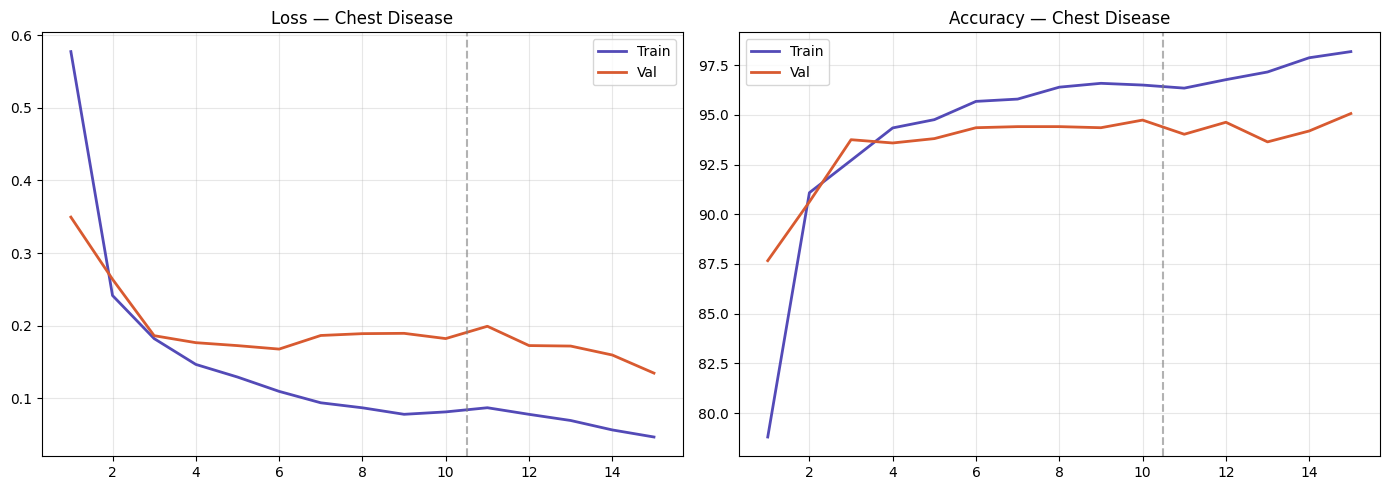

Eval: 100%|██████████| 57/57 [00:25<00:00,  2.20it/s]


              precision    recall  f1-score   support

       COVID       0.97      0.98      0.98       457
Lung_Opacity       0.94      0.94      0.94       460
      Normal       0.92      0.89      0.91       391
   Pneumonia       0.96      0.97      0.96       423
Tuberculosis       0.97      1.00      0.98        93

    accuracy                           0.95      1824
   macro avg       0.95      0.96      0.95      1824
weighted avg       0.95      0.95      0.95      1824



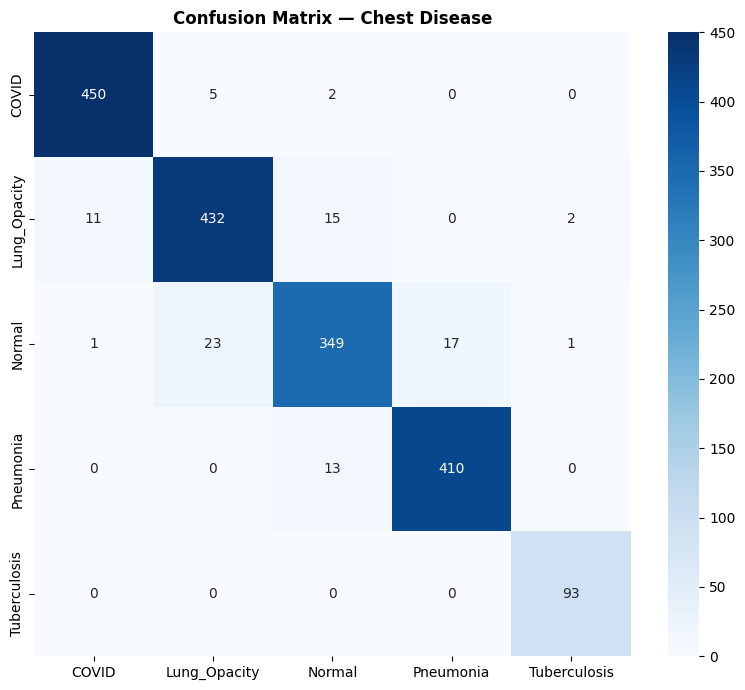

In [43]:
ep = range(1, 16)
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14,5))
ax1.plot(ep, history["train_loss"], color="#534AB7", label="Train", linewidth=2)
ax1.plot(ep, history["val_loss"],   color="#D85A30", label="Val",   linewidth=2)
ax1.axvline(x=10.5, color='gray', linestyle='--', alpha=0.6)
ax1.set_title("Loss — Chest Disease"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(ep, [a*100 for a in history["train_acc"]], color="#534AB7", label="Train", linewidth=2)
ax2.plot(ep, [a*100 for a in history["val_acc"]],   color="#D85A30", label="Val",   linewidth=2)
ax2.axvline(x=10.5, color='gray', linestyle='--', alpha=0.6)
ax2.set_title("Accuracy — Chest Disease"); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("/content/disease_curves.png", dpi=120); plt.show()

model.load_state_dict(torch.load(BEST)); model.eval()
all_p, all_l = [], []
with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc="Eval"):
        all_p.extend(model(imgs.to(device)).argmax(1).cpu().numpy())
        all_l.extend(labels.numpy())
print(classification_report(all_l, all_p, target_names=class_names))
cm = confusion_matrix(all_l, all_p)
fig, ax = plt.subplots(figsize=(8,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("Confusion Matrix — Chest Disease", fontweight='bold')
plt.tight_layout(); plt.savefig("/content/disease_cm.png", dpi=120); plt.show()



In [44]:
torch.save(model.state_dict(), "/content/disease_model.pth")
metadata = {
    "model_name":"ResNet50 Chest Disease Detector", "num_classes":len(class_names),
    "classes":class_names, "class_to_idx":{c:i for i,c in enumerate(class_names)},
    "input_size":[224,224], "normalize_mean":[0.485,0.456,0.406],
    "normalize_std":[0.229,0.224,0.225], "best_val_accuracy":round(best_acc*100,2),
    "scan_type":"Chest X-ray",
    "disease_info":{
        "Normal":{"description":"Healthy lungs","symptoms":["None"],"treatment":"None","risk":"None","emergency":False},
        "Pneumonia":{"description":"Lung infection","symptoms":["Cough","Fever","Breathlessness"],"treatment":"Antibiotics/antivirals","risk":"Moderate","emergency":False},
        "COVID":{"description":"COVID-19 lung infection","symptoms":["Fever","Dry cough","Loss of taste"],"treatment":"Supportive care, antivirals","risk":"Moderate-Critical","emergency":False},
        "Lung_Opacity":{"description":"Cloudy areas in lungs indicating fluid or infection","symptoms":["Breathlessness","Cough","Fatigue"],"treatment":"Treat underlying cause","risk":"Moderate","emergency":False},
        "Tuberculosis":{"description":"Bacterial lung infection","symptoms":["Persistent cough","Night sweats","Weight loss"],"treatment":"6-month RIPE antibiotics","risk":"High","emergency":False},
    }
}
with open("/content/disease_metadata.json","w") as f: json.dump(metadata, f, indent=2)

SAVE_DIR = "/content/drive/MyDrive/disease_data"
os.makedirs(SAVE_DIR, exist_ok=True)
for fp in ["/content/disease_model.pth","/content/disease_metadata.json",
           "/content/disease_curves.png","/content/disease_cm.png"]:
    shutil.copy2(fp, os.path.join(SAVE_DIR, os.path.basename(fp)))
    print(f"  Saved: {os.path.basename(fp)}")
print(f"\n✅ Best accuracy: {best_acc*100:.2f}%")

  Saved: disease_model.pth
  Saved: disease_metadata.json
  Saved: disease_curves.png
  Saved: disease_cm.png

✅ Best accuracy: 95.07%
